# Estimation of CX

This notebook presents the **estimation of cx** case and the core analysis workflow.

In [12]:
# !pip install causalis

Looking in indexes: https://artifactory.tcsbank.ru/artifactory/api/pypi/python-all/simple

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [7]:
import pandas as pd
import itertools

# Features
- **Target**
  - `target` — binary target variable (utilization of the product).

- **Treatments (problems)**
  - `contact_flg` / `contact` — contact / support request flag
  - `repeat_flg` / `repeat` — repeat application flag

- **Strong confounders (past applications/utilization history)**
  - `prev_apps` — past applications.
  - `prev_util` — past utilization events.

- **Features (covariates)**
  - `age` — age.
  - `channel` — application channel (categorical, typically one-hot encoded).
  - `region` — region (categorical, typically one-hot encoded).
  - `prev_contact` — past contact history.
  - `prev_repeat` — past repeat-application history.
  - `risk_latent` — latent risk factor.
  - `income` — income.
  - `sessions_30d` — sessions in the last 30 days.
  - `clicks_7d` — clicks in the last 7 days.
  - `n_products` — number of products.
  - `has_debt` — debt flag.
  - `csat_prev` — previous CSAT score.

- **Noise features**
  - `noise_1`, `noise_2` — no-signal features.

In [8]:
df = pd.read_csv('data.csv')
df.head()

,age,channel,region,risk_latent,income,sessions_30d,clicks_7d,n_products,has_debt,csat_prev,prev_contact,prev_repeat,prev_apps,prev_util,contact_flg,repeat_flg,target,product_emb_1,product_emb_2
0,37,partner,C,0.385767,142440.094699,10,20,2,1,3.839030,1,1,1,0,1,1,0,-0.819997,30
1,40,app,C,1.634347,55049.126762,12,16,1,1,3.628438,1,0,1,1,0,1,1,1.216887,98
2,34,web,C,0.883021,120028.233553,6,16,1,0,4.082905,0,1,1,1,0,0,1,0.305621,77
3,27,web,C,-1.552501,60504.458155,4,10,0,1,4.470721,0,0,0,0,0,0,0,-0.324429,72
4,32,web,D,0.488759,128068.614387,11,18,3,1,4.152280,0,0,0,0,0,0,0,1.062772,82


# Creating a Control Group and Extracting All Combinations of Problem Flags

In [9]:
problem_cols = ["contact_flg", "repeat_flg"]
df["control"] = (df[problem_cols].sum(axis=1) == 0).astype(int)

In [10]:
df["contact_flg+repeat_flg"] = ((df["contact_flg"] == 1) & (df["repeat_flg"] == 1)).astype(int)

mask = df["contact_flg+repeat_flg"] == 1
df.loc[mask, ["contact_flg", "repeat_flg"]] = 0

# Processing Categorical Features

In [14]:
cat_cols = ["channel", "region"]

df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# Creating MultiCausalData object

In [16]:
from causalis.data_contracts.multicausaldata import MultiCausalData

multi_causaldata = MultiCausalData(df = df,
                        treatment_names=['control', 'contact_flg', 'repeat_flg', 'contact_flg+repeat_flg'],
                        control_treatment= 'control',
                        outcome='target',
                        confounders=['age', 'risk_latent', 'income', 'sessions_30d',
       'clicks_7d', 'n_products', 'has_debt', 'csat_prev', 'prev_contact',
       'prev_repeat', 'prev_apps', 'prev_util', 'product_emb_1', 'product_emb_2', 'channel_callcenter', 'channel_partner', 'channel_web', 'region_B',
       'region_C', 'region_D'])
multi_causaldata

MultiCausalData(df=(200000, 25), treatment_names=['control', 'contact_flg', 'repeat_flg', 'contact_flg+repeat_flg'], control_treatment='control')outcome='target', confounders=['age', 'risk_latent', 'income', 'sessions_30d', 'clicks_7d', 'n_products', 'has_debt', 'csat_prev', 'prev_contact', 'prev_repeat', 'prev_apps', 'prev_util', 'product_emb_1', 'product_emb_2', 'channel_callcenter', 'channel_partner', 'channel_web', 'region_B', 'region_C', 'region_D'], user_id=None, 

# EDA

In [17]:
from causalis.shared import outcome_stats
outcome_stats(multi_causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,contact_flg+repeat_flg,26487,0.525654,0.499351,0,0.0,0.0,1.0,1.0,1.0,1
1,repeat_flg,35224,0.441744,0.496602,0,0.0,0.0,0.0,1.0,1.0,1
2,control,82557,0.491103,0.499924,0,0.0,0.0,0.0,1.0,1.0,1
3,contact_flg,55732,0.564613,0.495812,0,0.0,0.0,1.0,1.0,1.0,1


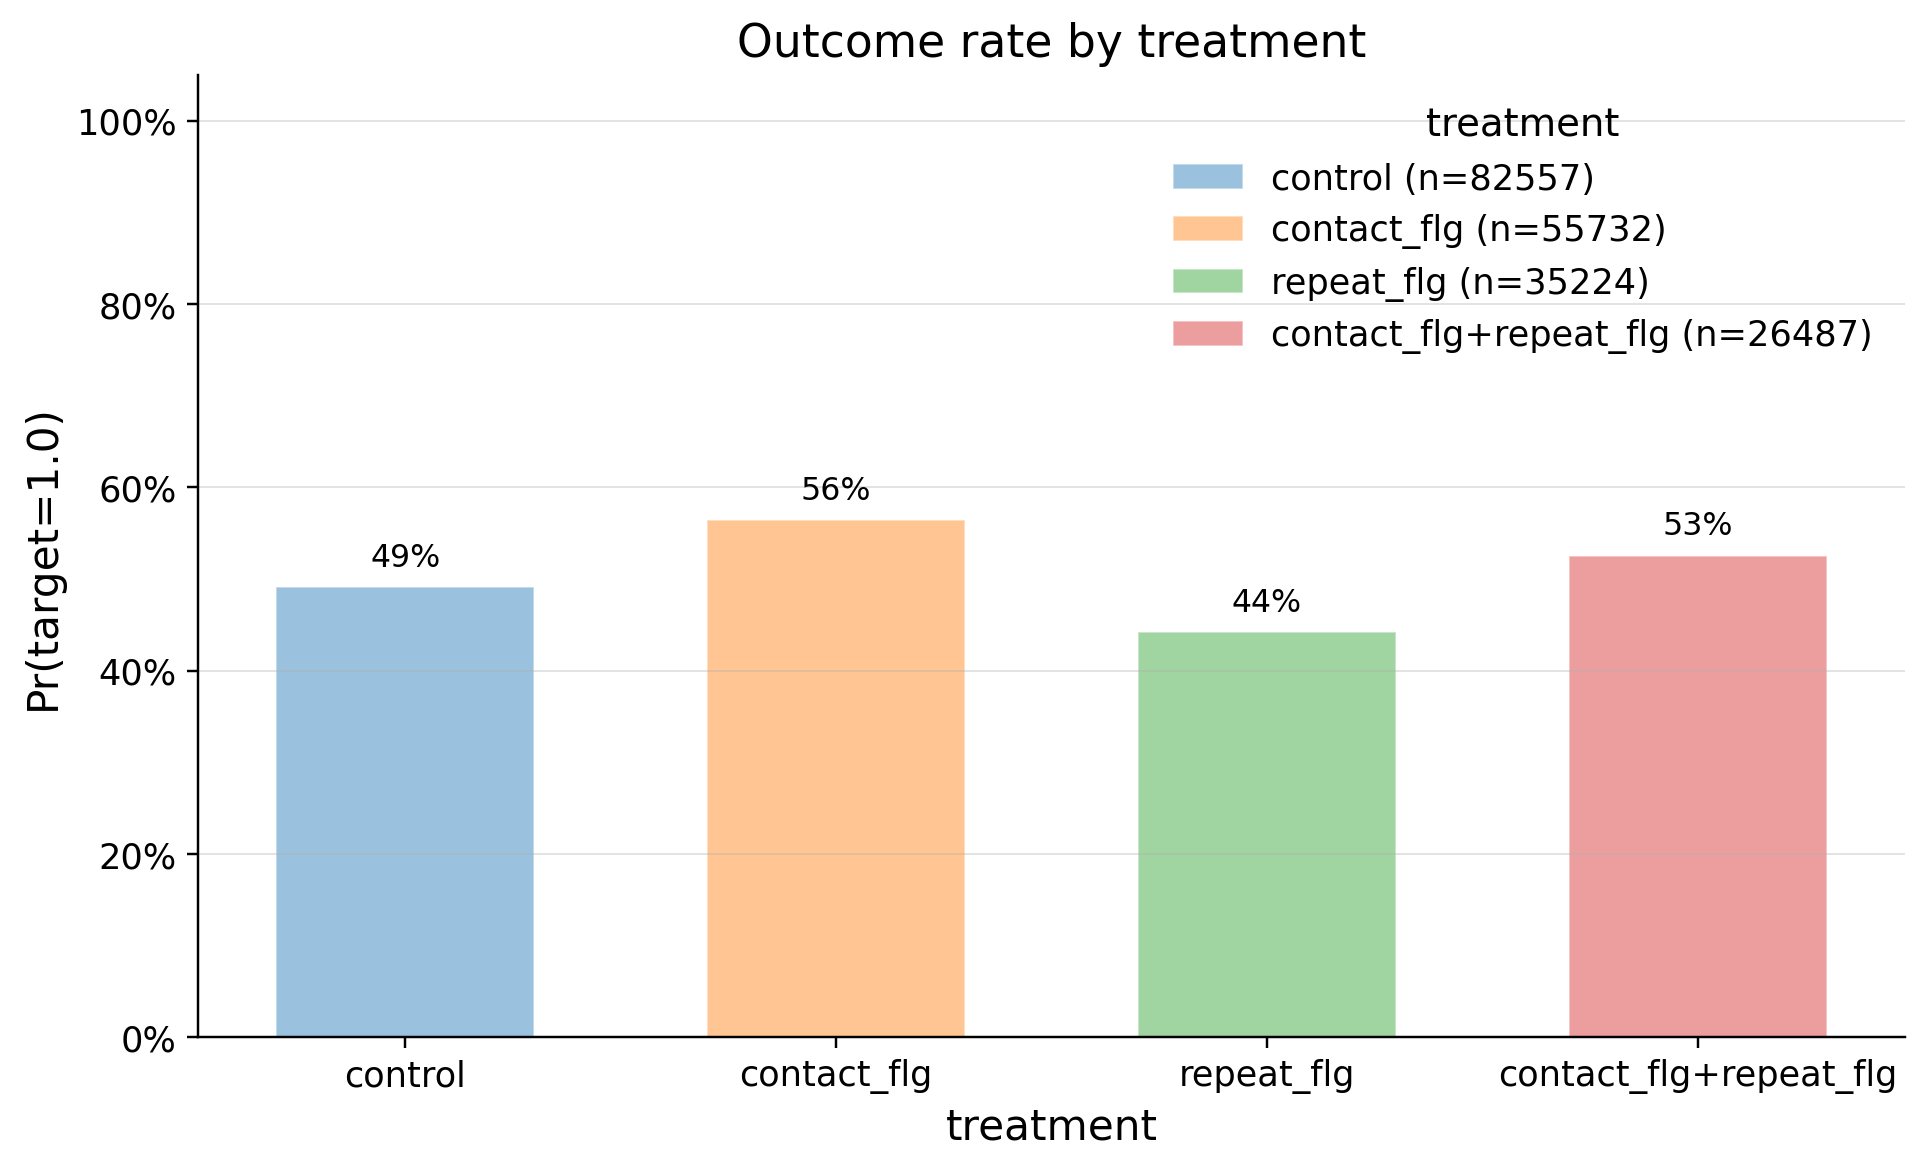

In [18]:
from causalis.shared.outcome_plots import outcome_plot_dist
outcome_plot_dist(multi_causaldata)

In [20]:
from causalis.shared import confounders_balance

confounders_balance(multi_causaldata, 'control', 'contact_flg')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,prev_contact,0.100101,0.469246,0.369145,0.896443,0.00000
1,csat_prev,4.112740,3.724429,0.388310,-0.659094,0.00000
2,risk_latent,-0.211026,0.116489,0.327515,0.335194,0.00000
3,sessions_30d,9.052642,9.664089,0.611446,0.194945,0.00000
4,prev_apps,0.245988,0.331784,0.085797,0.190146,0.00000
5,prev_util,0.316024,0.391427,0.075403,0.158196,0.00000
6,channel_callcenter,0.086413,0.118352,0.031939,0.105503,0.00000
7,has_debt,0.270068,0.310145,0.040077,0.088398,0.00000
8,income,83653.047517,86279.709434,2626.661917,0.087024,0.00000
9,channel_web,0.434427,0.401601,0.032827,-0.066590,0.00000


In [21]:
confounders_balance(multi_causaldata, 'control', 'repeat_flg')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,prev_repeat,0.120559,0.319157,0.198598,0.493934,0.00000
1,age,35.772860,40.395781,4.622921,0.444035,0.00000
2,risk_latent,-0.211026,0.019519,0.230544,0.235158,0.00000
3,prev_apps,0.245988,0.352572,0.106584,0.234336,0.00000
4,prev_util,0.316024,0.400068,0.084044,0.175977,0.00000
5,channel_web,0.434427,0.367193,0.067234,-0.137518,0.00000
6,has_debt,0.270068,0.315012,0.044945,0.098914,0.00000
7,channel_partner,0.135252,0.165853,0.030601,0.085647,0.00000
8,sessions_30d,9.052642,9.273478,0.220836,0.070931,0.00000
9,income,83653.047517,85463.647875,1810.600358,0.059862,0.00000


In [22]:
confounders_balance(multi_causaldata, 'control', 'contact_flg+repeat_flg')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,prev_contact,0.100101,0.457054,0.356954,0.867981,0.00000
1,csat_prev,4.112740,3.726233,0.386507,-0.655882,0.00000
2,risk_latent,-0.211026,0.357222,0.568248,0.579695,0.00000
3,prev_repeat,0.120559,0.309246,0.188687,0.471978,0.00000
4,prev_apps,0.245988,0.458602,0.212615,0.456537,0.00000
5,age,35.772860,40.321327,4.548467,0.435771,0.00000
6,prev_util,0.316024,0.480273,0.164249,0.340353,0.00000
7,sessions_30d,9.052642,9.899875,0.847233,0.268205,0.00000
8,channel_web,0.434427,0.335825,0.098602,-0.203670,0.00000
9,has_debt,0.270068,0.360026,0.089958,0.194563,0.00000


# Training the Model and Reviewing the Results

In [23]:
from causalis.scenarios.multi_unconfoundedness import MultiTreatmentIRM

model = MultiTreatmentIRM().fit(multi_causaldata)

In [24]:
dml_result = model.estimate(score='ATE')
dml_result.summary()

,contact_flg vs control,repeat_flg vs control,contact_flg+repeat_flg vs control
field,,,
estimand,ATE,ATE,ATE
model,MultiTreatmentIRM,MultiTreatmentIRM,MultiTreatmentIRM
value,"0.0089 (ci_abs: 0.0024, 0.0154)","-0.1335 (ci_abs: -0.1413, -0.1256)","-0.1258 (ci_abs: -0.1349, -0.1167)"
value_relative,"1.6345 (ci_rel: 0.4270, 2.8419)","-24.5095 (ci_rel: -25.8666, -23.1525)","-23.1048 (ci_rel: -24.7120, -21.4976)"
alpha,0.0500,0.0500,0.0500
p_value,0.0076,0.0000,0.0000
is_significant,True,True,True
n_treated,55732,35224,26487
n_control,82557,82557,82557


# Refutation

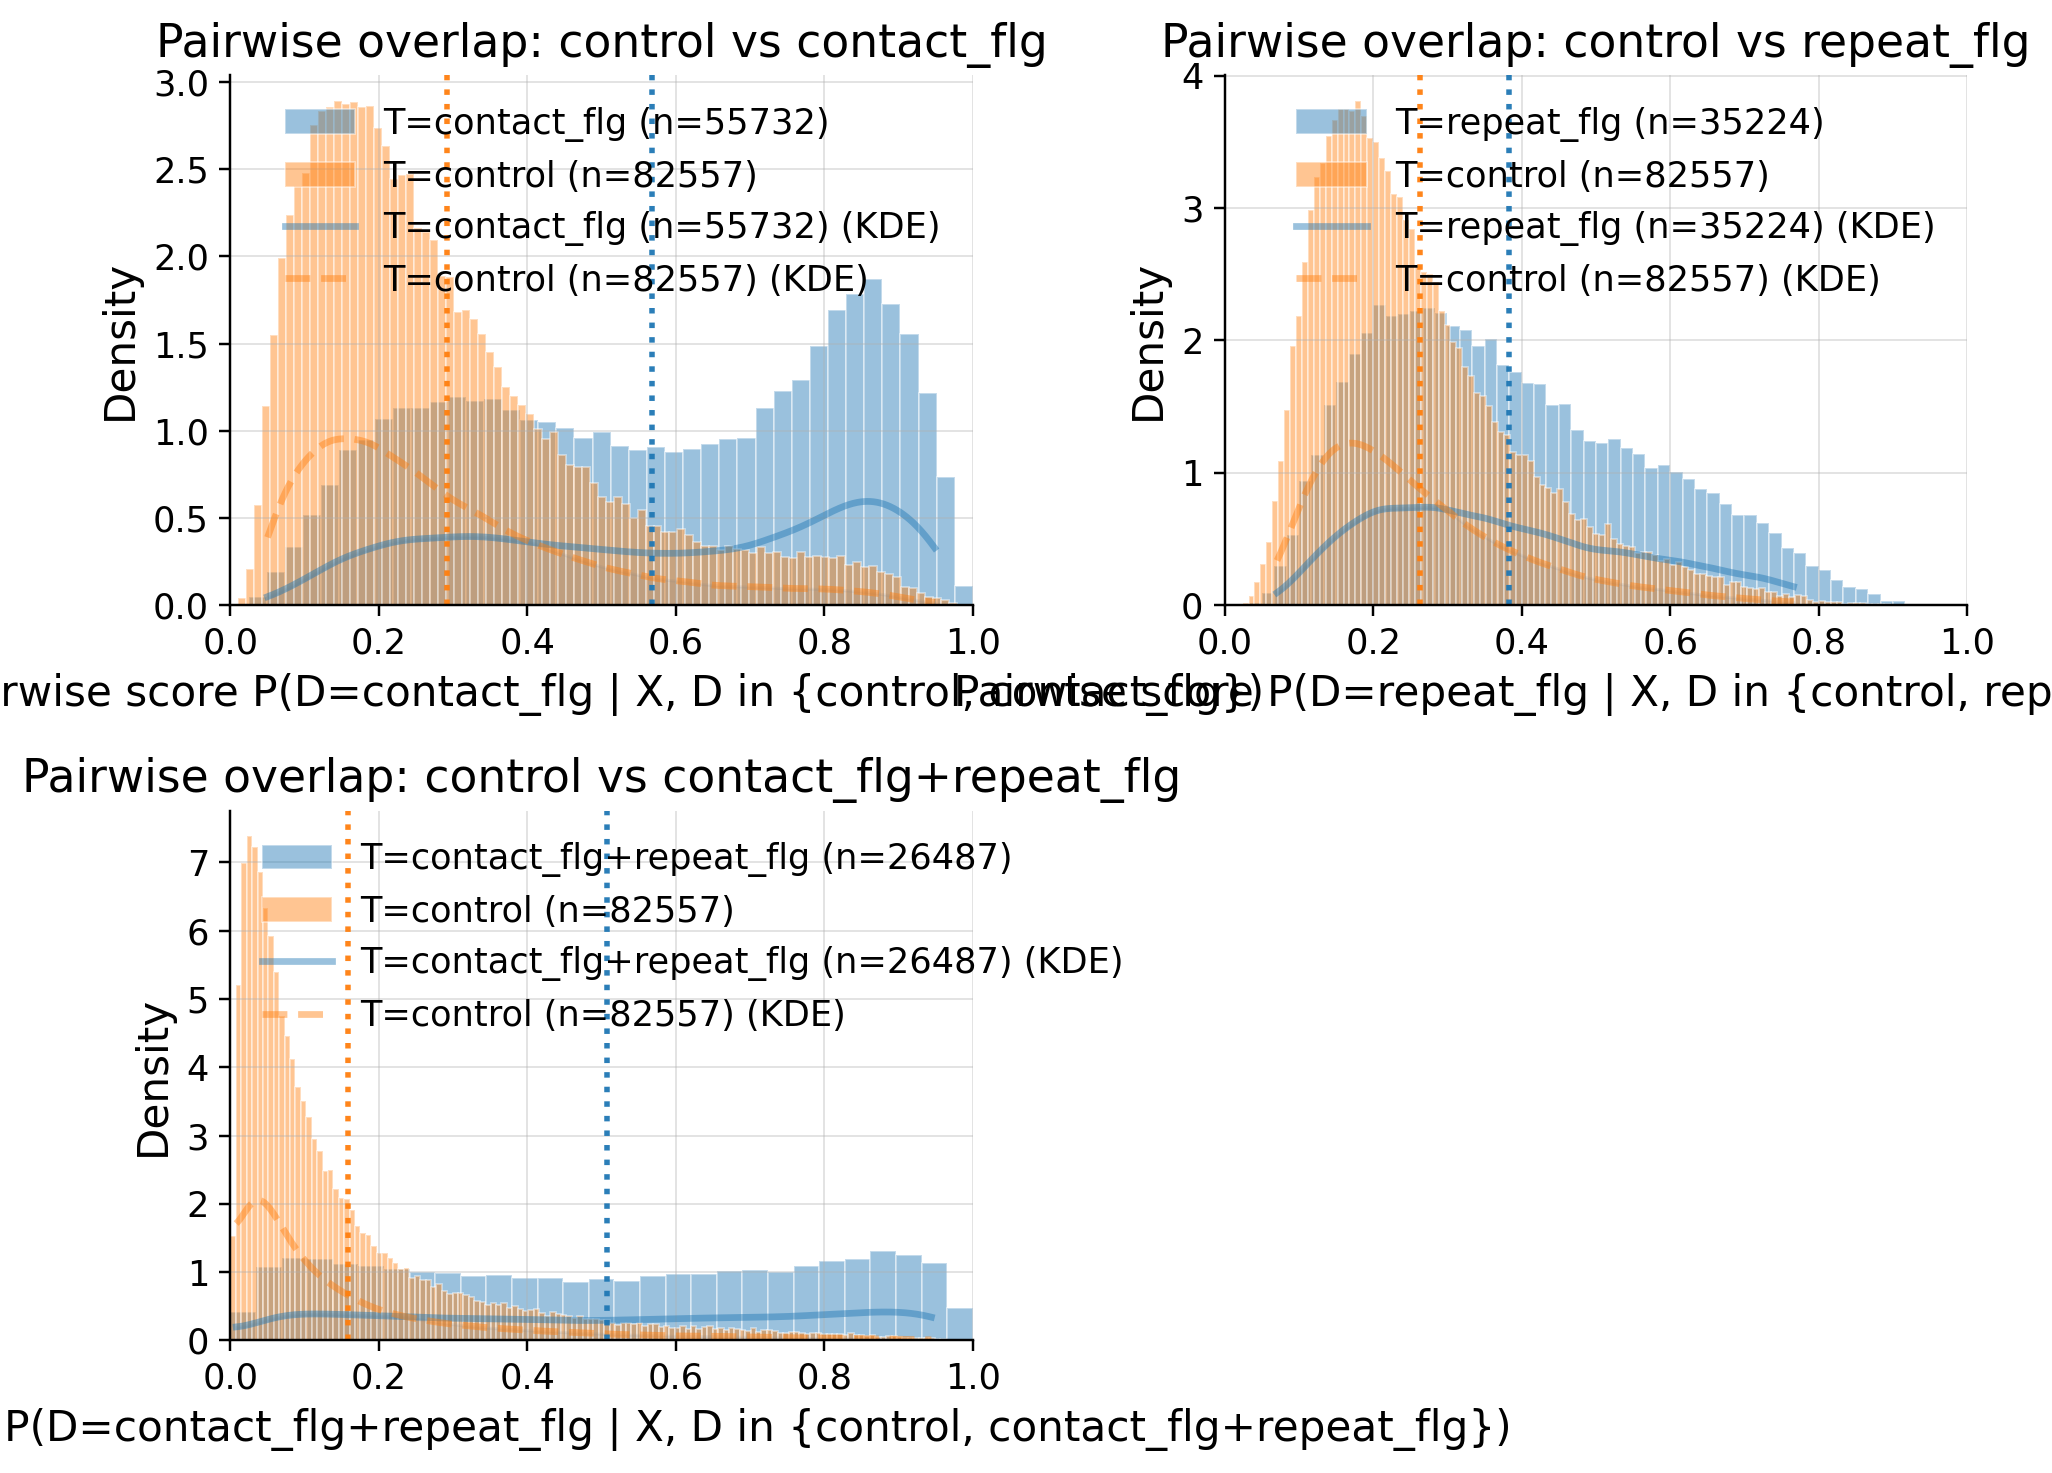

In [26]:
from causalis.scenarios.multi_unconfoundedness.refutation.overlap import overlap_plot

overlap_plot(multi_causaldata, dml_result)

In [27]:
from causalis.scenarios.multi_unconfoundedness.refutation.overlap import run_overlap_diagnostics
rep_overlap = run_overlap_diagnostics(multi_causaldata, dml_result)
rep_overlap["summary"]

,comparison,metric,value,flag
0,control vs contact_flg,edge_0.01_below,0.0,GREEN
1,control vs contact_flg,edge_0.01_above,0.000043,GREEN
2,control vs contact_flg,KS,0.447947,RED
3,control vs contact_flg,AUC,0.796797,GREEN
4,control vs contact_flg,ESS_treated_ratio,0.555034,GREEN
5,control vs contact_flg,ESS_baseline_ratio,0.514845,GREEN
6,control vs contact_flg,clip_m_total,0.000311,GREEN
7,control vs contact_flg,overlap_pass,False,RED
8,control vs repeat_flg,edge_0.01_below,0.0,GREEN
9,control vs repeat_flg,edge_0.01_above,0.0,GREEN


# Unconfoundedness

In [29]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness import run_unconfoundedness_diagnostics
rep_uc = run_unconfoundedness_diagnostics(multi_causaldata, dml_result)
rep_uc["summary"]  # comparison, metric, value, flag

,comparison,metric,value,flag
0,control vs contact_flg,balance_max_smd,0.009223,GREEN
1,control vs contact_flg,balance_frac_violations,0.0,GREEN
2,control vs contact_flg,balance_pass,True,GREEN
3,control vs repeat_flg,balance_max_smd,0.007114,GREEN
4,control vs repeat_flg,balance_frac_violations,0.0,GREEN
5,control vs repeat_flg,balance_pass,True,GREEN
6,control vs contact_flg+repeat_flg,balance_max_smd,0.012058,GREEN
7,control vs contact_flg+repeat_flg,balance_frac_violations,0.0,GREEN
8,control vs contact_flg+repeat_flg,balance_pass,True,GREEN
9,overall,balance_max_smd,0.012058,GREEN


# Sensetivity analysis

In [30]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness.sensitivity import (
    sensitivity_analysis, get_sensitivity_summary
)

In [31]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness import sensitivity_benchmark


bench = sensitivity_benchmark(dml_result, benchmarking_set=["prev_contact", "prev_util"])
bench

,cf_y,r2_y,r2_d,rho,theta_long,theta_short,delta
contact_flg vs control,0.000001,0.000001,2.664076e-08,0.809016,0.008900,0.026240,-0.017340
repeat_flg vs control,0.000001,0.000001,6.940863e-08,0.161812,-0.133467,-0.119449,-0.014017
contact_flg+repeat_flg vs control,0.000001,0.000001,8.045872e-08,0.992336,-0.125817,-0.096686,-0.029131


In [32]:
res = sensitivity_analysis(
    dml_result,                      # MultiCausalEstimate
    multi_causaldata,                     # MultiCausalData (optional but recommended for validation)
    cf_y=0.05,                # confounding strength in outcome residual
    r2_d=0.05,                # confounding strength in treatment residual
    rho=1.0,
    H0=0.0,
    alpha=0.05,
)

res

{'theta': array([ 0.00890043, -0.1334666 , -0.12581707]),
 'se': array([0.00333344, 0.0040065 , 0.00465656]),
 'alpha': 0.05,
 'z': 1.959963984540054,
 'H0': 0.0,
 'sampling_ci': array([[ 0.002367  ,  0.01543385],
        [-0.14131919, -0.125614  ],
        [-0.13494376, -0.11669039]]),
 'theta_bounds_cofounding': array([[-0.06417842,  0.08197927],
        [-0.22189051, -0.04504269],
        [-0.23274665, -0.01888749]]),
 'bias_aware_ci': array([[-0.07083093,  0.08860606],
        [-0.22991316, -0.0368851 ],
        [-0.24217129, -0.00942154]]),
 'max_bias_base': array([1.42456887, 1.72369925, 2.08444125]),
 'max_bias': array([0.07307884, 0.08842391, 0.10692958]),
 'bound_width': array([0.07307884, 0.08842391, 0.10692958]),
 'sigma2': 0.19893996360682534,
 'nu2': array([10.20104979, 14.93485304, 21.84023376]),
 'rv': array([0.00078009, 0.1070704 , 0.06791786]),
 'rva': array([5.52123612e-05, 9.60160526e-02, 5.89819074e-02]),
 'contrast_labels': ['contact_flg vs control',
  'repeat_flg 

# SUTVA

In [33]:
from causalis.shared import print_sutva_questions
print_sutva_questions()

1.) Are your clients independent (i). Outcome of ones do not depend on others?
2.) Are all clients have full window to measure metrics?
3.) Do you measure confounders before treatment and outcome after?
4.) Do you have a consistent label of treatment, such as if a person does not receive a treatment, he has a label 0?


# Summary
A regular contact/support request is not a problem, while submitting the application multiple times leads to a decrease in product utilization.